# 04 — Runtime Comparison

Loads results from notebooks 01–03 and produces a unified comparison table and charts.

**Prerequisites:** Run notebooks 01, 02, 03 first.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score

RESULTS_DIR = Path('../results')

paddle_df = pd.read_csv(RESULTS_DIR / 'paddle_results.csv')
onnx_df   = pd.read_csv(RESULTS_DIR / 'onnx_results.csv')
opt_df    = pd.read_csv(RESULTS_DIR / 'optimum_results.csv')

print('Rows per result file:', len(paddle_df), len(onnx_df), len(opt_df))

Rows per result file: 552 552 552


In [2]:
runtimes = {
    'PaddlePaddle': ('paddle_pred',   'paddle_latency_ms',   paddle_df),
    'ONNX Runtime': ('onnx_pred',     'onnx_latency_ms',     onnx_df),
    'Optimum ORT':  ('optimum_pred',  'optimum_latency_ms',  opt_df),
}

rows = []
for name, (pred_col, lat_col, df) in runtimes.items():
    acc = accuracy_score(df['label'], df[pred_col])
    avg_lat = df[lat_col].mean()
    p50 = df[lat_col].quantile(0.50)
    p95 = df[lat_col].quantile(0.95)
    throughput = 1000 / avg_lat
    rows.append({
        'Runtime': name,
        'Accuracy': round(acc, 4),
        'Avg Latency (ms)': round(avg_lat, 2),
        'P50 Latency (ms)': round(p50, 2),
        'P95 Latency (ms)': round(p95, 2),
        'Throughput (img/s)': round(throughput, 1),
    })

summary = pd.DataFrame(rows).set_index('Runtime')
summary.to_csv(RESULTS_DIR / 'comparison_summary.csv')
summary

,Accuracy,Avg Latency (ms),P50 Latency (ms),P95 Latency (ms),Throughput (img/s)
Runtime,,,,,
PaddlePaddle,0.9692,39.53,39.42,46.54,25.3
ONNX Runtime,0.9692,34.14,33.53,43.87,29.3
Optimum ORT,0.9692,32.00,32.23,39.15,31.2


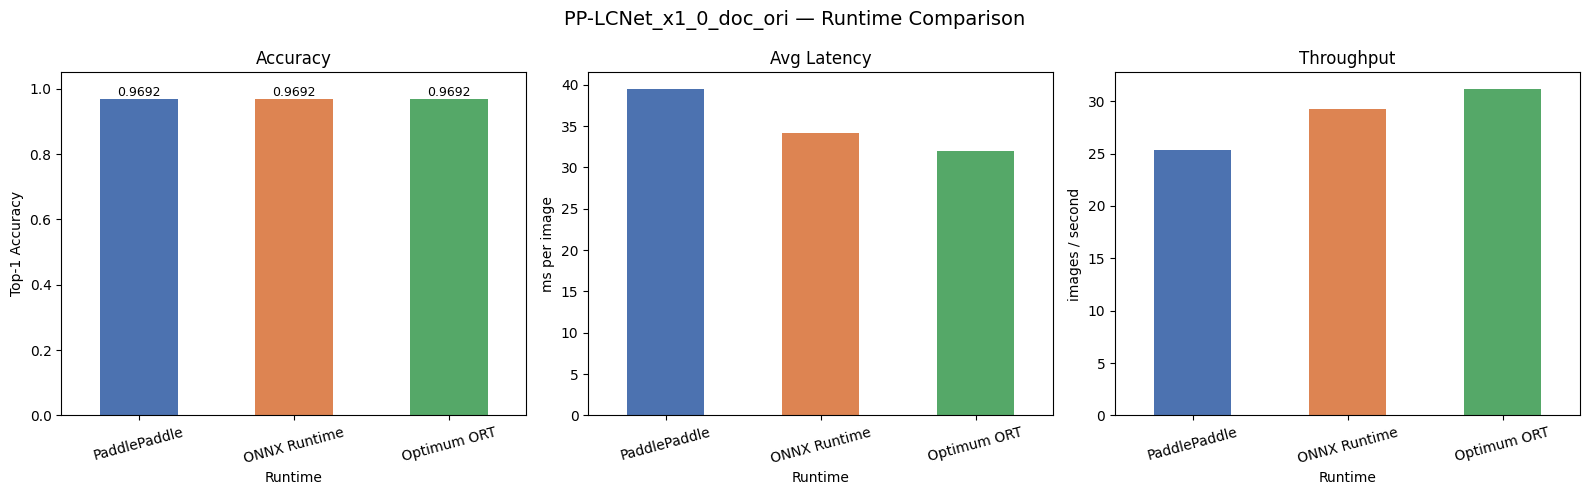

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
summary['Accuracy'].plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'], rot=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Top-1 Accuracy')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Avg Latency
summary['Avg Latency (ms)'].plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452','#55A868'], rot=15)
axes[1].set_title('Avg Latency')
axes[1].set_ylabel('ms per image')

# Throughput
summary['Throughput (img/s)'].plot(kind='bar', ax=axes[2], color=['#4C72B0','#DD8452','#55A868'], rot=15)
axes[2].set_title('Throughput')
axes[2].set_ylabel('images / second')

plt.suptitle('PP-LCNet_x1_0_doc_ori — Runtime Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_chart.png', dpi=150)
plt.show()

/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_77717/3513031203.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(lat_data.values(), labels=lat_data.keys())


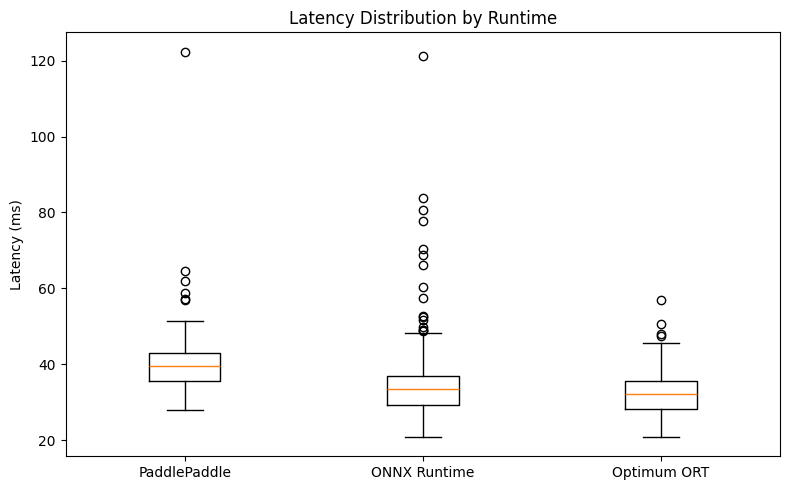

In [4]:
# Latency distribution boxplot
import numpy as np

lat_data = {
    'PaddlePaddle': paddle_df['paddle_latency_ms'].values,
    'ONNX Runtime': onnx_df['onnx_latency_ms'].values,
    'Optimum ORT':  opt_df['optimum_latency_ms'].values,
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(lat_data.values(), labels=lat_data.keys())
ax.set_ylabel('Latency (ms)')
ax.set_title('Latency Distribution by Runtime')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latency_boxplot.png', dpi=150)
plt.show()

In [5]:
# Prediction agreement between runtimes (sanity check)
agree_onnx_paddle   = (paddle_df['paddle_pred'] == onnx_df['onnx_pred']).mean()
agree_opt_paddle    = (paddle_df['paddle_pred'] == opt_df['optimum_pred']).mean()
agree_onnx_opt      = (onnx_df['onnx_pred']    == opt_df['optimum_pred']).mean()

print('Prediction agreement:')
print(f'  PaddlePaddle vs ONNX Runtime : {agree_onnx_paddle:.4f}')
print(f'  PaddlePaddle vs Optimum ORT  : {agree_opt_paddle:.4f}')
print(f'  ONNX Runtime vs Optimum ORT  : {agree_onnx_opt:.4f}')
print()
print('If agreement < 1.0, preprocessing or conversion may differ — investigate.')

Prediction agreement:
  PaddlePaddle vs ONNX Runtime : 1.0000
  PaddlePaddle vs Optimum ORT  : 1.0000
  ONNX Runtime vs Optimum ORT  : 1.0000

If agreement < 1.0, preprocessing or conversion may differ — investigate.


## Findings & Recommendation

*(Fill in after running all experiments)*

| Question | Finding |
|---|---|
| Accuracy parity? | |
| Fastest runtime? | |
| Optimum overhead vs raw ORT? | |
| Any orientation class harder than others? | |
| **Recommended runtime for production?** | |